In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew



In [2]:
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

df_train = pd.read_csv('../data/KDDTrain.txt', names=col_names)
df_test = pd.read_csv('../data/KDDTest.txt', names=col_names)


df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [3]:
df_train.info()
df_train.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
df_train['label'].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [5]:
df_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [6]:
df_train['binary_label'] = (df_train['label'] != 'normal').astype(int)
df_train['binary_label'].value_counts()

binary_label
0    67343
1    58630
Name: count, dtype: int64

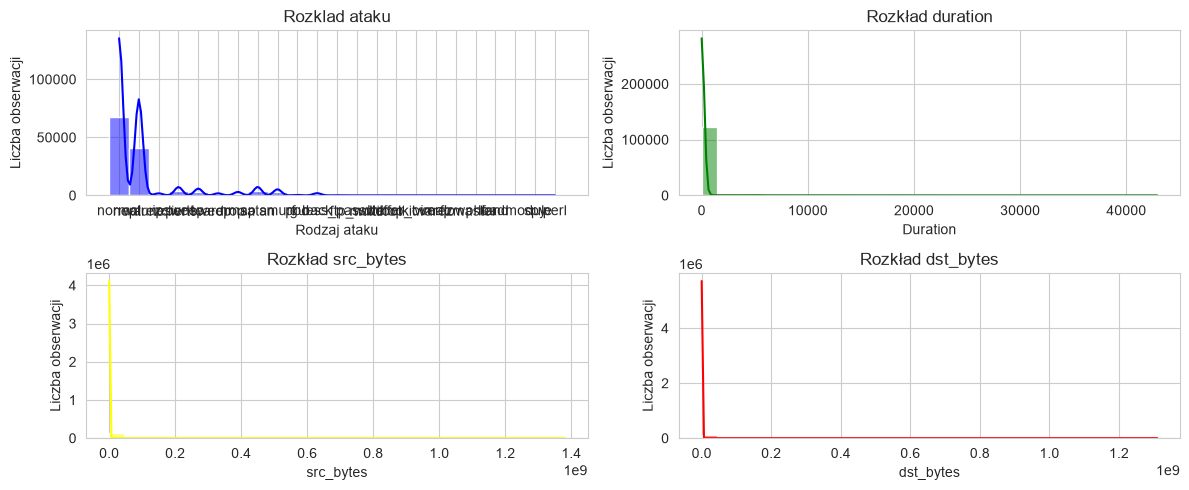

In [7]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)

sns.histplot(df_train['label'], bins=30, kde=True, color="blue")
plt.xlabel("Rodzaj ataku")
plt.ylabel('Liczba obserwacji')
plt.title("Rozklad ataku")

plt.subplot(2, 2, 2)
sns.histplot(df_train['duration'], bins=30, kde=True, color="green")
plt.xlabel("Duration")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład duration")

plt.subplot(2, 2, 3)
sns.histplot(df_train['src_bytes'], bins=30, kde=True, color="yellow")
plt.xlabel("src_bytes")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład src_bytes")

plt.subplot(2, 2, 4)
sns.histplot(df_train['dst_bytes'], bins=30, kde=True, color="red")
plt.xlabel("dst_bytes")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład dst_bytes")
  
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'src_bytes'}>,
        <Axes: title={'center': 'dst_bytes'}>,
        <Axes: title={'center': 'land'}>,
        <Axes: title={'center': 'wrong_fragment'}>,
        <Axes: title={'center': 'urgent'}>],
       [<Axes: title={'center': 'hot'}>,
        <Axes: title={'center': 'num_failed_logins'}>,
        <Axes: title={'center': 'logged_in'}>,
        <Axes: title={'center': 'num_compromised'}>,
        <Axes: title={'center': 'root_shell'}>,
        <Axes: title={'center': 'su_attempted'}>],
       [<Axes: title={'center': 'num_root'}>,
        <Axes: title={'center': 'num_file_creations'}>,
        <Axes: title={'center': 'num_shells'}>,
        <Axes: title={'center': 'num_access_files'}>,
        <Axes: title={'center': 'num_outbound_cmds'}>,
        <Axes: title={'center': 'is_host_login'}>],
       [<Axes: title={'center': 'is_guest_login'}>,
        <Axes: title={'center': 'count'}>,
        <Axes: title

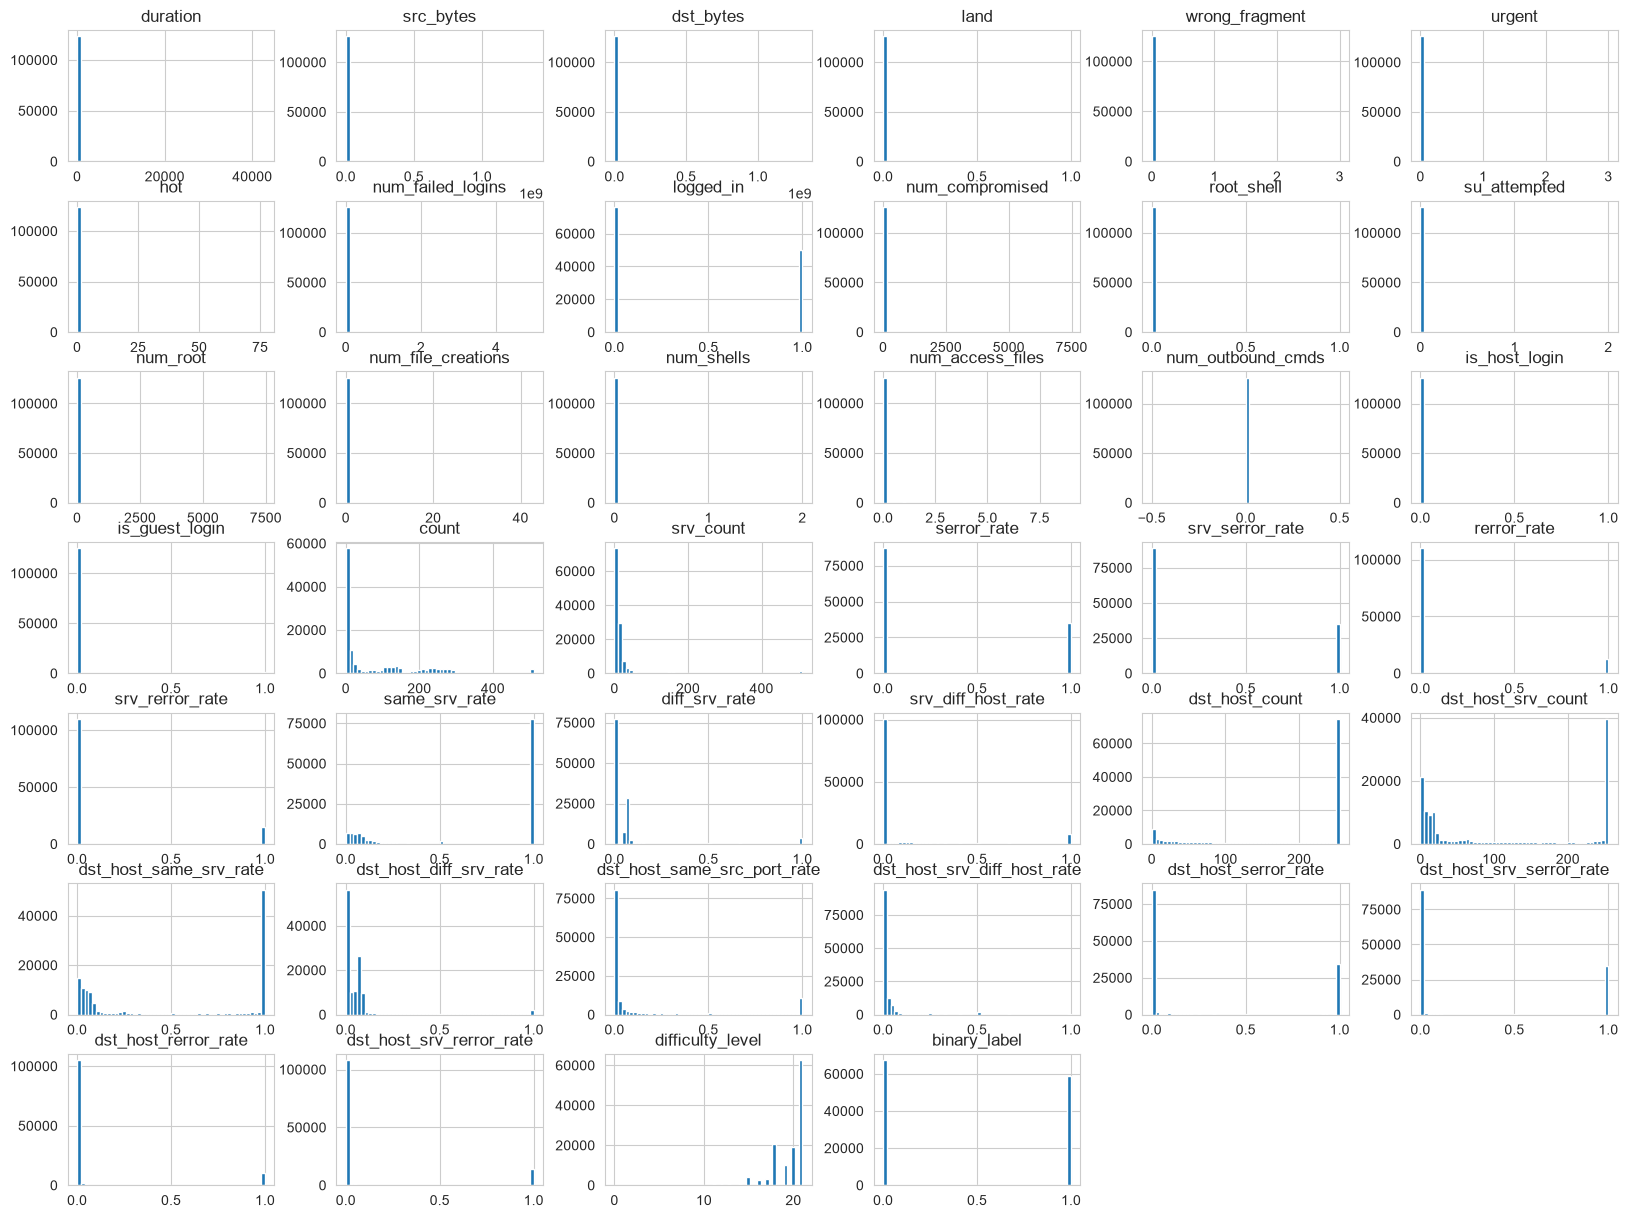

In [8]:
#histogramy
df_train.hist(bins=50, figsize = (20, 15))

#obserwacja: kolujny src_bytes, dst_bytes, duration maja bardzo wysokie std
#wzgedem mean - bedzie potrzebnyfeature scaling przed modelowaniem

array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'src_bytes'}>,
        <Axes: title={'center': 'dst_bytes'}>,
        <Axes: title={'center': 'land'}>,
        <Axes: title={'center': 'wrong_fragment'}>,
        <Axes: title={'center': 'urgent'}>],
       [<Axes: title={'center': 'hot'}>,
        <Axes: title={'center': 'num_failed_logins'}>,
        <Axes: title={'center': 'logged_in'}>,
        <Axes: title={'center': 'num_compromised'}>,
        <Axes: title={'center': 'root_shell'}>,
        <Axes: title={'center': 'su_attempted'}>],
       [<Axes: title={'center': 'num_root'}>,
        <Axes: title={'center': 'num_file_creations'}>,
        <Axes: title={'center': 'num_shells'}>,
        <Axes: title={'center': 'num_access_files'}>,
        <Axes: title={'center': 'num_outbound_cmds'}>,
        <Axes: title={'center': 'is_host_login'}>],
       [<Axes: title={'center': 'is_guest_login'}>,
        <Axes: title={'center': 'count'}>,
        <Axes: title

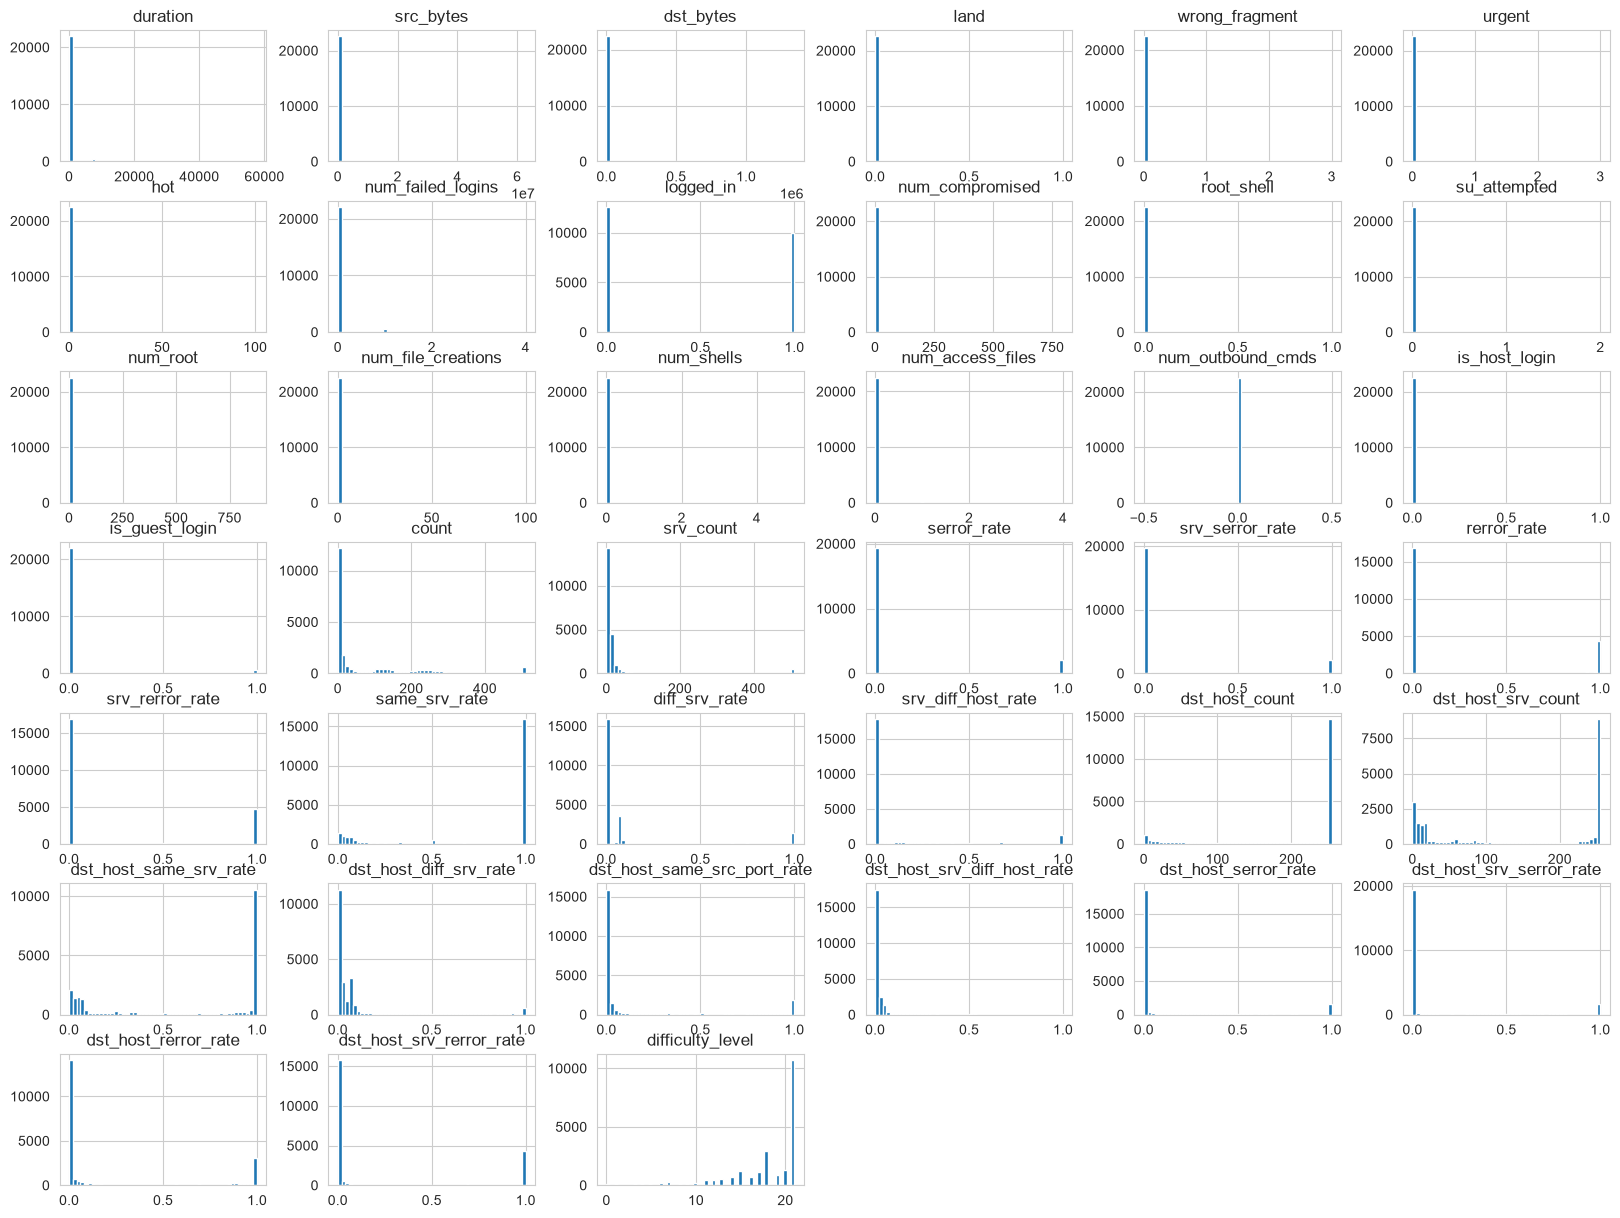

In [9]:
df_test.hist(bins=50, figsize=(20, 15))

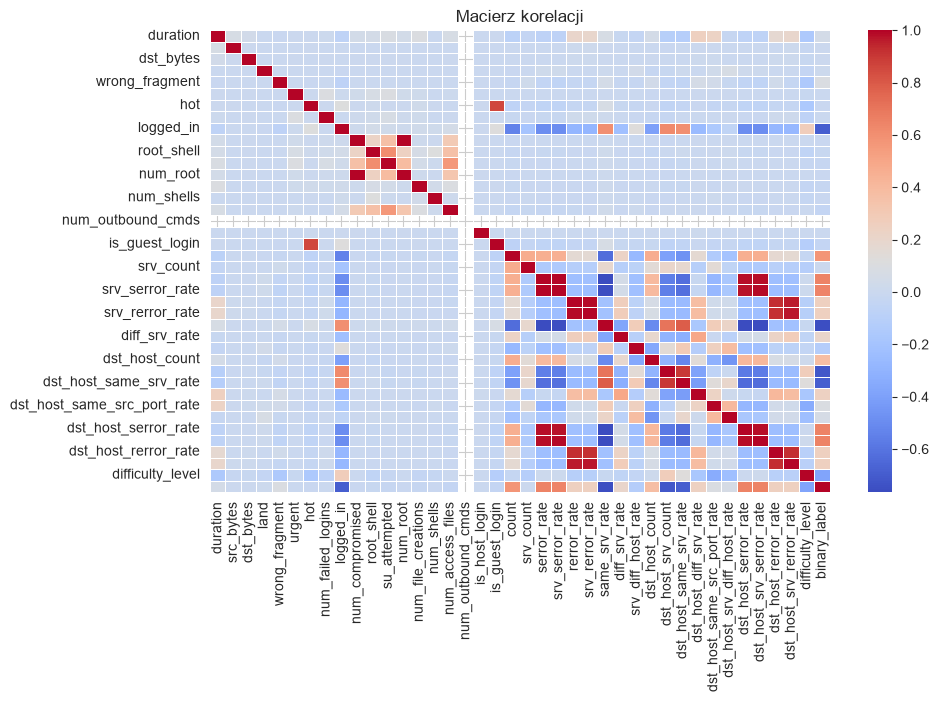

In [10]:
#correlation mattix

correlation_matrix = df_train.select_dtypes(include="number").corr()



plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=False,  cmap='coolwarm', linewidths=0.5)
plt.title('Macierz korelacji')
plt.show()

In [11]:
correlation_matrix['binary_label'].sort_values(ascending=False)

binary_label                   1.000000
dst_host_srv_serror_rate       0.654985
dst_host_serror_rate           0.651842
serror_rate                    0.650652
srv_serror_rate                0.648289
count                          0.576444
dst_host_count                 0.375052
srv_rerror_rate                0.253504
dst_host_srv_rerror_rate       0.253430
rerror_rate                    0.253397
dst_host_rerror_rate           0.252563
dst_host_diff_srv_rate         0.242898
diff_srv_rate                  0.203660
wrong_fragment                 0.095905
dst_host_same_src_port_rate    0.092444
dst_host_srv_diff_host_rate    0.062332
duration                       0.048785
land                           0.007191
src_bytes                      0.005921
dst_bytes                      0.004118
srv_count                      0.000771
is_host_login                 -0.002629
urgent                        -0.002787
num_failed_logins             -0.003755
num_shells                    -0.009472


In [12]:
#rozklady cech wykazujacych skosnosc
numerical_cols = df_train.select_dtypes(include=['number']).columns
skewness_values = df_train[numerical_cols].skew().sort_values(ascending=False)

skewness_values

is_host_login                  354.926753
dst_bytes                      290.052911
num_compromised                250.107883
num_root                       236.913724
src_bytes                      190.669347
urgent                         149.914509
land                            70.965063
num_shells                      59.592151
num_file_creations              55.665341
num_failed_logins               53.764424
num_access_files                45.554961
su_attempted                    42.435591
root_shell                      27.247411
hot                             12.589886
duration                        11.880230
wrong_fragment                  11.457988
is_guest_login                  10.155746
dst_host_srv_diff_host_rate      5.548174
srv_count                        4.694162
diff_srv_rate                    4.379815
dst_host_diff_srv_rate           3.609600
srv_diff_host_rate               2.860355
dst_host_rerror_rate             2.347446
dst_host_srv_rerror_rate         2

In [13]:
df_test['binary_label'] = (df_test['label'] != 'normal').astype(int)

X_train = df_train.drop(['label', 'binary_label', 'difficulty_level', 'num_outbound_cmds'], axis=1)
y_train = df_train['binary_label']


X_test = df_test.drop(['label', 'binary_label', 'difficulty_level', 'num_outbound_cmds'], axis=1)
y_test = df_test['binary_label']

In [14]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(125973, 40) (125973,)
(22544, 40) (22544,)


array([[<Axes: title={'center': 'dst_bytes'}>,
        <Axes: title={'center': 'num_compromised'}>],
       [<Axes: title={'center': 'num_root'}>,
        <Axes: title={'center': 'src_bytes'}>],
       [<Axes: title={'center': 'urgent'}>, <Axes: >]], dtype=object)

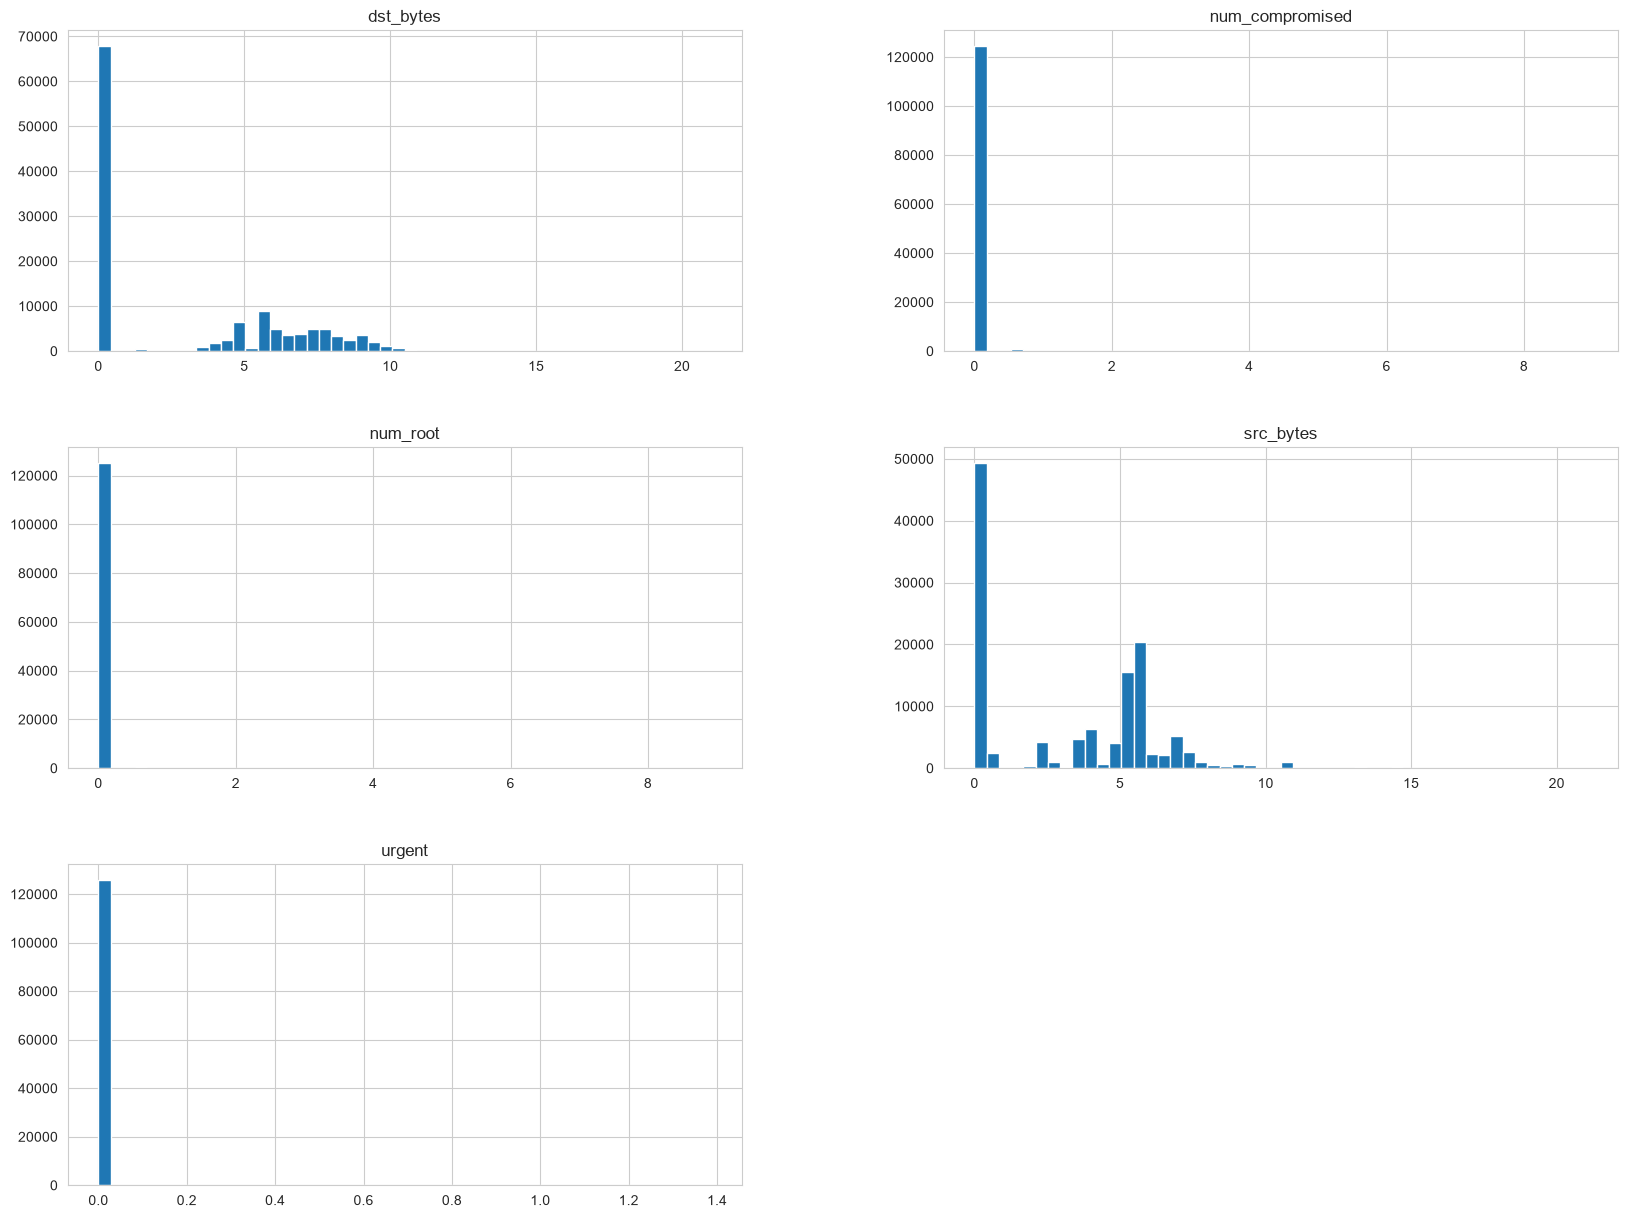

In [15]:
'''
dst_bytes                      290.052911
num_compromised                250.107883
num_root                       236.913724
src_bytes 
'''
skewed_cols = ['dst_bytes', 'num_compromised', 'num_root', 'src_bytes', 'urgent']

X_train[skewed_cols] = np.log1p(X_train[skewed_cols])
X_test[skewed_cols] = np.log1p(X_test[skewed_cols])

X_train[skewed_cols].hist(bins = 50, figsize=(20, 15))



In [16]:
numerical_cols = X_train.select_dtypes(include=['number']).columns
skew_values_X_train = X_train[numerical_cols].skew().sort_values(ascending=False)

skew_values_X_train

is_host_login                  354.926753
urgent                         131.652162
land                            70.965063
num_shells                      59.592151
num_file_creations              55.665341
num_failed_logins               53.764424
num_access_files                45.554961
su_attempted                    42.435591
num_compromised                 27.506888
root_shell                      27.247411
num_root                        26.428761
hot                             12.589886
duration                        11.880230
wrong_fragment                  11.457988
is_guest_login                  10.155746
dst_host_srv_diff_host_rate      5.548174
srv_count                        4.694162
diff_srv_rate                    4.379815
dst_host_diff_srv_rate           3.609600
srv_diff_host_rate               2.860355
dst_host_rerror_rate             2.347446
dst_host_srv_rerror_rate         2.337926
srv_rerror_rate                  2.327033
rerror_rate                      2

In [17]:
X_train = pd.get_dummies(X_train, columns=['protocol_type', 'service', 'flag'])
X_test = pd.get_dummies(X_test, columns=['protocol_type', 'service', 'flag'])

X_train

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,6.198479,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0,4.990433,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0,0.000000,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0,5.451038,9.006264,0,0,0.0,0,0,1,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0,5.298317,6.042633,0,0,0.0,0,0,1,0.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0.000000,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,True,False,False,False,False,False
125969,8,4.663439,4.983607,0,0,0.0,0,0,0,0.0,...,False,False,False,False,False,False,False,False,True,False
125970,0,7.710653,5.953243,0,0,0.0,0,0,1,0.0,...,False,False,False,False,False,False,False,False,True,False
125971,0,0.000000,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,True,False,False,False,False,False


In [18]:
print(X_train.shape, X_test.shape)

(125973, 121) (22544, 115)


In [25]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,6.198479,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0,4.990433,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0,0.000000,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0,5.451038,9.006264,0,0,0.0,0,0,1,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0,5.298317,6.042633,0,0,0.0,0,0,1,0.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0.000000,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,True,False,False,False,False,False
125969,8,4.663439,4.983607,0,0,0.0,0,0,0,0.0,...,False,False,False,False,False,False,False,False,True,False
125970,0,7.710653,5.953243,0,0,0.0,0,0,1,0.0,...,False,False,False,False,False,False,False,False,True,False
125971,0,0.000000,0.000000,0,0,0.0,0,0,0,0.0,...,False,False,False,False,True,False,False,False,False,False


In [20]:
print(X_train.shape)
print(X_test.shape)

(125973, 121)
(22544, 121)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[-0.11024922,  0.99551712, -0.8691111 , ..., -0.01972622,
         0.82515007, -0.04643159],
       [-0.11024922,  0.59042868, -0.8691111 , ..., -0.01972622,
         0.82515007, -0.04643159],
       [-0.11024922, -1.08298964, -0.8691111 , ..., -0.01972622,
        -1.21190076, -0.04643159],
       ...,
       [-0.11024922,  1.50258753,  0.80837254, ..., -0.01972622,
         0.82515007, -0.04643159],
       [-0.11024922, -1.08298964, -0.8691111 , ..., -0.01972622,
        -1.21190076, -0.04643159],
       [-0.11024922,  0.60164462, -0.8691111 , ..., -0.01972622,
         0.82515007, -0.04643159]], shape=(125973, 121))

In [22]:
skewed_cols = ['dst_bytes', 'num_compromised', 'num_root', 'src_bytes', 'urgent']

X_train_scaled['skewed_cols'].hist(bins=20, figsize=(20, 15))

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(solver='lbfgs', max_iter=5000, verbose=2, class_weight='balanced', random_state=42 )
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred ))

In [ ]:
# precision 0.92 - jesli model krzyczy "atak"  - ma racje na 92% - malo falszywych alarmow
# recall 0.64 - ze wszystkich atakow model wykryl poprawnie tylko 64% czyli 36% przeszlo niezauwazonych.
# CEL - podbic recall